# SHAP Explainability

- SHAP value - Measures how much each feature contributes to the model's prediction across all transactions.
- Higher values indicate that the feature has a larger influence on whether the model predicts a transaction as fraudulent or legitimate.

We're using the validation set for model explainability as it will take too long to run on the test set.

In [1]:
import joblib
import pandas as pd

X_train = pd.read_csv('data/X_train_final.csv')
X_val   = pd.read_csv('data/X_val_final.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()
y_val   = pd.read_csv('data/y_val.csv').squeeze()
lgbm_final = joblib.load('models/lgbm_final.pkl')

# Verify
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"Model expects: {lgbm_final.n_features_in_} features")
print(f"Match: {X_val.shape[1] == lgbm_final.n_features_in_}")

X_train: (472432, 314)
X_val:   (118108, 314)
Model expects: 314 features
Match: True


In [2]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Setup SHAP explainer
# Sample for speed — SHAP on 1000 rows gives reliable explanations
sample_size = 1000
X_sample = X_val.sample(n=sample_size, random_state=42)
y_sample = y_val.loc[X_sample.index]

# TreeExplainer is optimised for tree-based models
explainer   = shap.TreeExplainer(lgbm_final)
shap_values = explainer.shap_values(X_sample)

# For binary classification LightGBM returns list of [class0, class1]
# We want class 1 (fraud)
if isinstance(shap_values, list):
    shap_fraud = shap_values[1]
else:
    shap_fraud = shap_values

print(f"SHAP values shape: {shap_fraud.shape}")
print(f"Features: {X_sample.shape[1]}")

C:\Users\Mansi Jadhav\.conda\envs\ieee-cis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (1000, 314)
Features: 314


C:\Users\Mansi Jadhav\.conda\envs\ieee-cis\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 1. Global Feature Importance

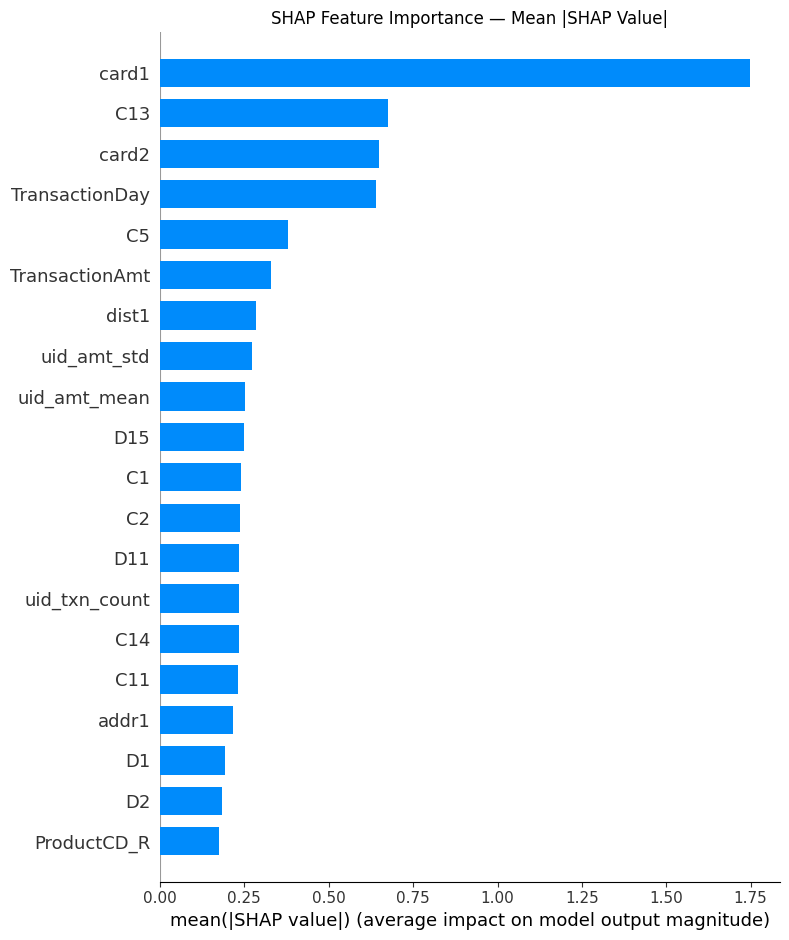

In [3]:
#  Global feature importance (mean |SHAP|)
plt.figure(figsize=(5, 5))
shap.summary_plot(
    shap_fraud, 
    X_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — Mean |SHAP Value|')
plt.tight_layout()
plt.show()

- card1 is by far the most influential feature.
- Some engineered features like uid aggregates and TransactionDay are also quite influential.

## 2. Beeswarm Plot

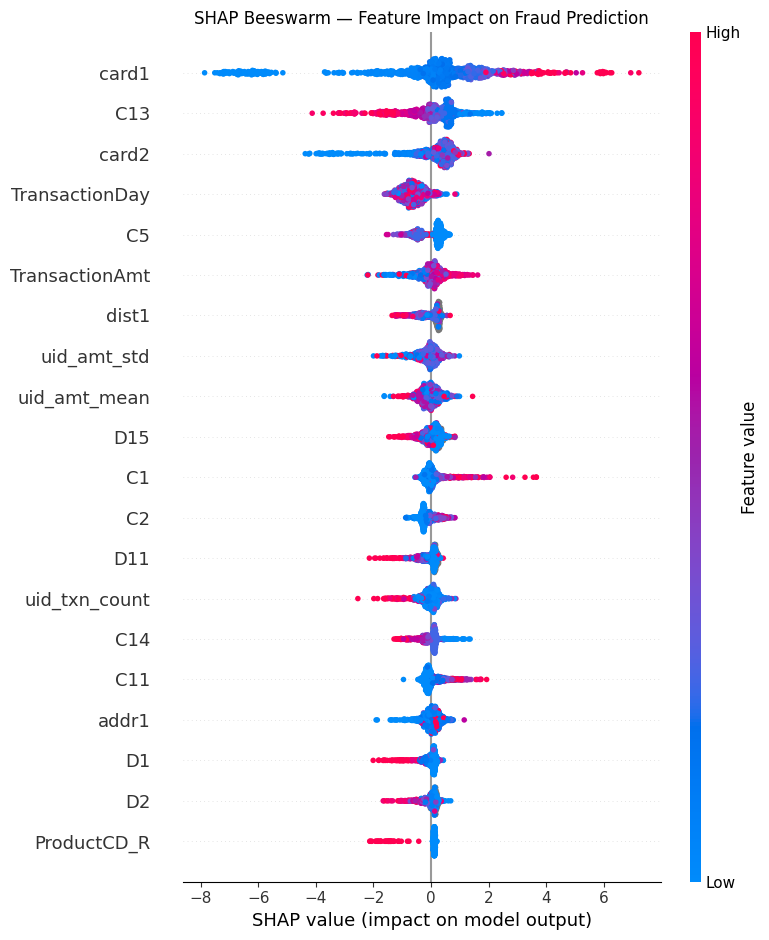

In [4]:
# Beeswarm — shows direction of impact
# Each dot = one transaction
# Red = high feature value, Blue = low feature value
# X position = impact on fraud prediction
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_fraud,
    X_sample,
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact on Fraud Prediction')
plt.tight_layout()
plt.show()

Each point represents one transaction.

Horizontal position = impact on prediction  
Right (positive SHAP) → pushes prediction towards fraud  
Left (negative SHAP) → pushes prediction towards legitimate  
Red = high feature value  
Blue = low feature value  

The wider the spread, the more influence that feature has.  

- card1 - Largest spread of SHAP values. - High card1 values (red) generally push predictions towards fraud. - Low values often decrease fraud probability. - This indicates that certain customer/card IDs are associated with substantially higher fraud risk.
- C13 - Inverse relationship = Larger C13 values reduce fraud probability, while smaller values tend to increase predicted fraud risk.
- card2 - No specific relationship.
- TransactionDay - Almost all SHAP values remain close to zero. - Although TransactionDay appears in the top features, its individual contribution is relatively modest, suggesting that the model captures small temporal shifts rather than strong day-specific fraud patterns.

The beeswarm plot reveals not only feature importance but also the direction of influence. While card-based features strongly separate fraudulent and legitimate transactions, behavioural features contribute more subtle adjustments to the predicted fraud probability.

## 3. Dependence Plot

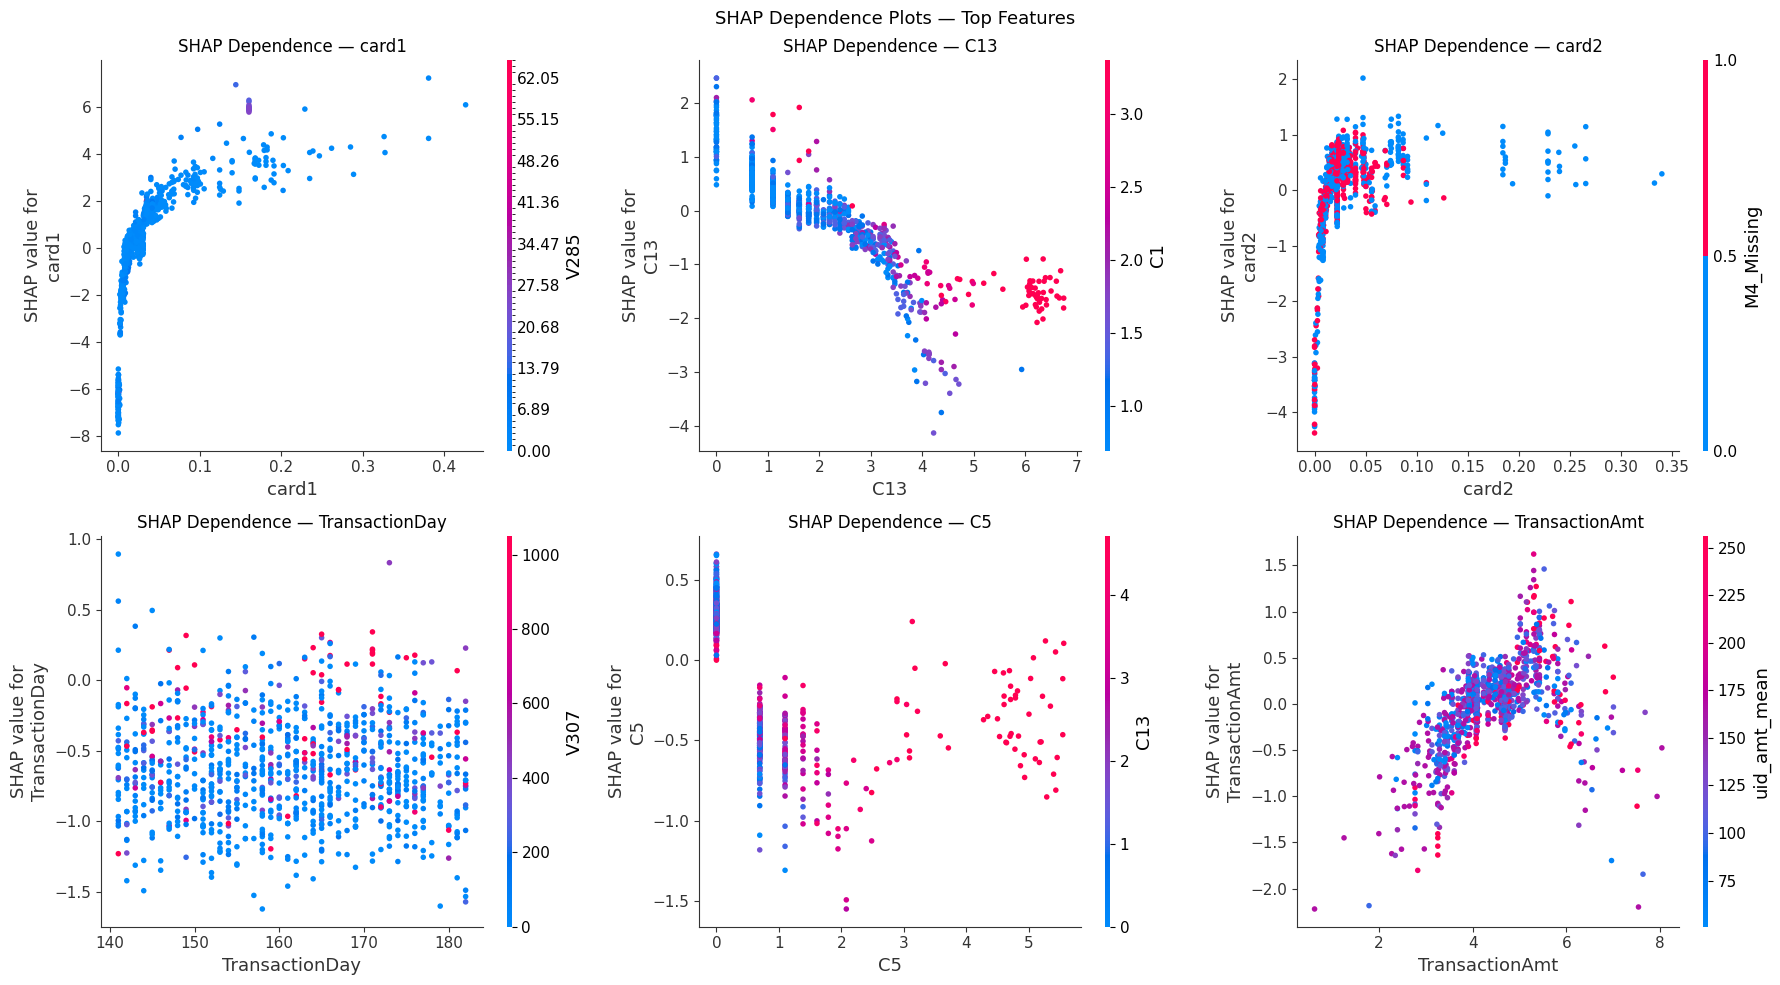

In [5]:
# Dependence plots for top features
# Shows how a feature's value affects its SHAP value
top_features = ['card1', 'C13', 'card2', 
                'TransactionDay', 'C5', 'TransactionAmt']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    if feat in X_sample.columns:
        feat_idx = list(X_sample.columns).index(feat)
        shap.dependence_plot(
            feat_idx,
            shap_fraud,
            X_sample,
            ax=axes[i],
            show=False
        )
        axes[i].set_title(f'SHAP Dependence — {feat}')

plt.suptitle('SHAP Dependence Plots — Top Features', fontsize=13)
plt.tight_layout()
plt.show()

These plots examine how each feature's value affects its SHAP contribution.
- card1 - There is a strong nonlinear relationship. Very small values tend to decrease fraud probability. As card1 increases, SHAP values increase rapidly before gradually plateauing. This indicates that the model has learned specific card ranges associated with elevated fraud risk rather than a simple linear relationship.
- C13 - A clear decreasing trend is visible. As C13 increases, SHAP values become increasingly negative. Therefore, larger C13 values consistently reduce predicted fraud probability. The colouring (C1) suggests interactions between C13 and C1, meaning the effect of C13 depends partly on another transaction characteristic.
- card2 - The relationship is non-linear. Most observations occur near small card2 values, where SHAP contributions vary substantially.
- TransactionDay - Points remain tightly centred around negative SHAP values. No obvious trend is visible across time. This indicates TransactionDay contributes only minor adjustments rather than acting as a major fraud indicator.
- C5 - Lower C5 values generally produce SHAP values close to zero. Larger values increasingly reduce fraud probability. Again, this agrees with the beeswarm plot.
- TransactionAmt - A nonlinear pattern appears. Small transaction amounts generally reduce fraud probability. Moderate transaction amounts increase fraud probability. Extremely large amounts show greater variability, indicating interactions with other features. This suggests transaction amount alone is insufficient for identifying fraud but becomes informative when combined with other behavioural variables.

## 4. Individual Transaction Explanation

=== Explaining a FRAUD transaction ===


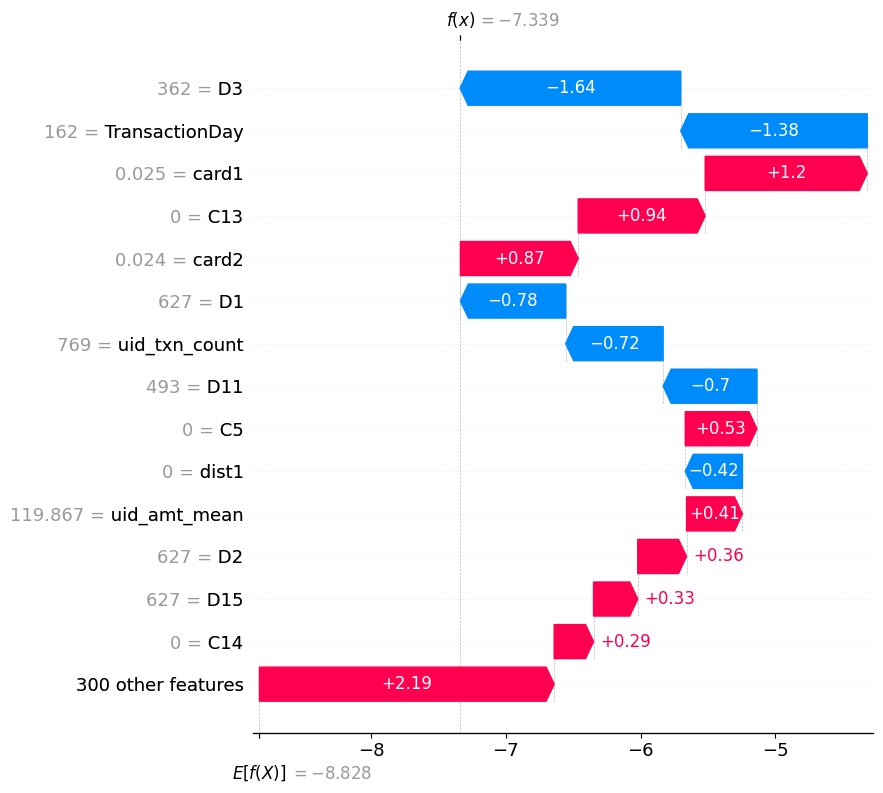


=== Explaining a LEGITIMATE transaction ===


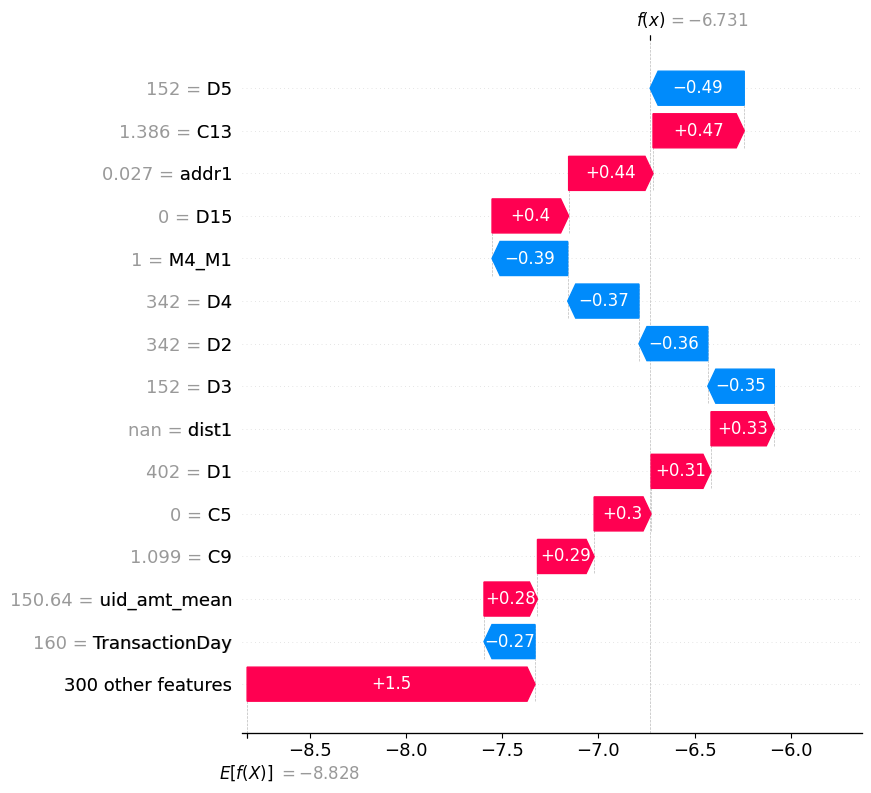

In [6]:
# Individual transaction explanation
# Pick one fraud case and one legitimate case and explain them

fraud_idx   = y_sample[y_sample == 1].index[0]
legit_idx   = y_sample[y_sample == 0].index[0]

fraud_pos   = X_sample.index.get_loc(fraud_idx)
legit_pos   = X_sample.index.get_loc(legit_idx)

print("=== Explaining a FRAUD transaction ===")
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_fraud[fraud_pos],
        base_values = explainer.expected_value[1] if isinstance(
                        explainer.expected_value, list) 
                        else explainer.expected_value,
        data        = X_sample.iloc[fraud_pos],
        feature_names = X_sample.columns.tolist()
    ),
    max_display=15,
    show=True
)

print("\n=== Explaining a LEGITIMATE transaction ===")
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_fraud[legit_pos],
        base_values = explainer.expected_value[1] if isinstance(
                        explainer.expected_value, list) 
                        else explainer.expected_value,
        data        = X_sample.iloc[legit_pos],
        feature_names = X_sample.columns.tolist()
    ),
    max_display=15,
    show=True
)

- E[f(X)] = -8.828 — the base value, the model's average prediction across all transactions in log-odds space.
- f(x) — the model's prediction for this specific transaction in log-odds space.
- Red bars — push the prediction toward fraud (increase fraud probability).
- Blue bars — push the prediction away from fraud (decrease fraud probability).
- The bars stack from the base value to the final prediction.

The values are in log-odds, not probabilities. The more negative f(x) is, the lower the fraud probability.

Individual Transaction SHAP Explanations:

Fraud transaction (f(x) = -7.339 vs base -8.828):
- Key fraud signals: card1 identity (+1.2), zero legitimacy counts C13/C5 (+0.94/+0.53), card2 BIN range (+0.87).
- Counteracting legitimate signals: D3 long timedelta (-1.64), late TransactionDay (-1.38), high uid_txn_count of 769 (-0.72).
- This is a borderline case — established UID history partially offsets suspicious card and count signals.

Legitimate transaction (f(x) = -6.731 vs base -8.828):
- Surprisingly, the model assigns higher fraud probability to this legitimate transaction than to the actual fraud case above.
- Key fraud-pushing signals: addr1 fraud history (+0.44), missing dist1 (+0.33), zero C5 count (+0.3).
- Key legitimate signals: D5 long timedelta (-0.49), M4 match status (-0.39), multiple D feature timedeltas (-0.35 to -0.36).

This pair illustrates the precision-recall tradeoff: the model is more confident about some fraud cases than others, and legitimate transactions with unusual feature combinations can score higher than borderline fraud.

Key insight from SHAP individual explanations:  
No single feature determines the outcome — fraud detection relies on the combination of signals. A transaction can have strong legitimate signals (high uid_txn_count, long timedeltas) and still be flagged if identity and count signals are sufficiently suspicious. This mirrors real fraud ring behaviour where fraudsters build up legitimate history before executing high-value fraud.

## 5. SHAP values for Fraud v/s Legitimate

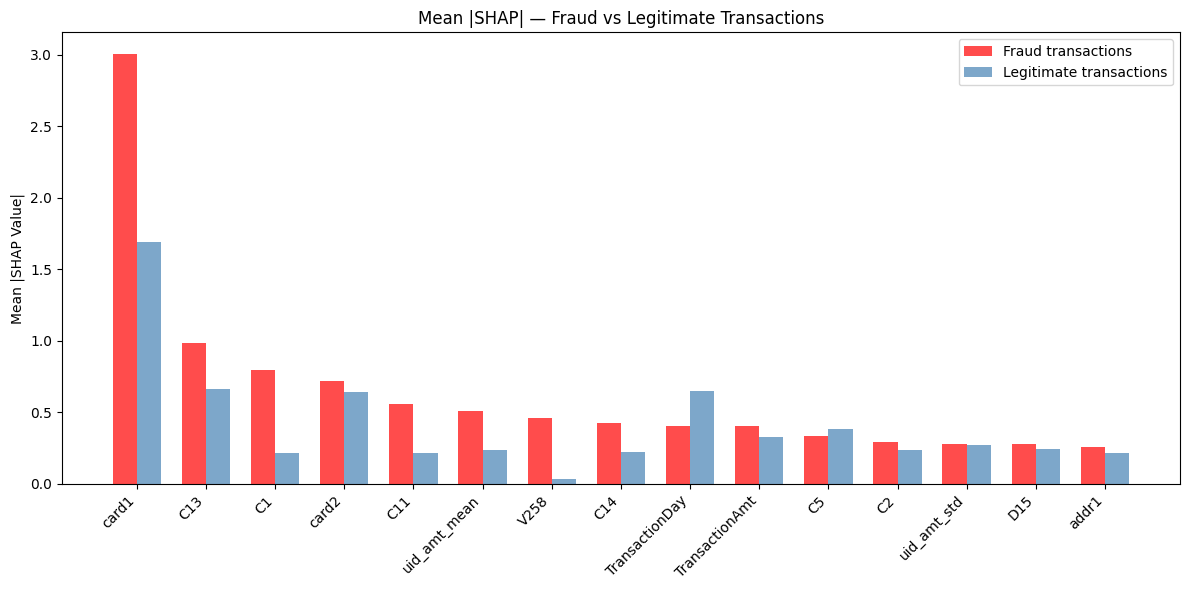

In [7]:
# SHAP values for fraud vs legitimate
# Compare mean SHAP magnitude for fraud cases vs legitimate cases

fraud_mask  = y_sample.values == 1
legit_mask  = y_sample.values == 0

mean_shap_fraud = np.abs(shap_fraud[fraud_mask]).mean(axis=0)
mean_shap_legit = np.abs(shap_fraud[legit_mask]).mean(axis=0)

shap_comparison = pd.DataFrame({
    'feature':       X_sample.columns,
    'fraud_impact':  mean_shap_fraud,
    'legit_impact':  mean_shap_legit,
}).sort_values('fraud_impact', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(shap_comparison))
width = 0.35

ax.bar(x - width/2, shap_comparison['fraud_impact'], 
       width, label='Fraud transactions', color='red', alpha=0.7)
ax.bar(x + width/2, shap_comparison['legit_impact'],
       width, label='Legitimate transactions', color='steelblue', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(shap_comparison['feature'], rotation=45, ha='right')
ax.set_title('Mean |SHAP| — Fraud vs Legitimate Transactions')
ax.set_ylabel('Mean |SHAP Value|')
ax.legend()
plt.tight_layout()
plt.show()

- This compares the average magnitude of each feature's SHAP contribution separately for Fraudulent transactions and Legitimate transactions.
- Larger values indicate that the feature played a stronger role in the model's decision for that class.

- card1 has substantially larger SHAP values for fraudulent transactions than legitimate ones, confirming that it is the primary driver of fraud detection.
- Features such as C13, C1, uid_amt_mean, C14, V258, and TransactionAmt also contribute more strongly when identifying fraudulent transactions.
- In contrast, TransactionDay exhibits slightly larger SHAP values for legitimate transactions, suggesting it is more useful for recognising normal temporal behaviour than fraud itself.
- Several features (for example uid_amt_std, D15, addr1) contribute similarly across both classes, indicating that they provide useful contextual information regardless of the predicted outcome.

## Conclusion:

This project delivers a complete end-to-end fraud detection system built on the IEEE-CIS Fraud Detection dataset, spanning exploratory data analysis, feature engineering, modelling, and explainability.

---

### Key EDA Findings

**Class imbalance:** Only 3.5% of transactions are fraudulent. This required stratified evaluation metrics (AUC-ROC, PR-AUC) and class weight adjustment during training — accuracy alone would be meaningless here.

**Temporal patterns:** Fraud peaks between hours 1–6 AM when transaction volume is lowest. Fraudsters exploit low-activity windows to avoid detection. TransactionDay was among the top features, reflecting concept drift — fraud patterns shifted across the 182-day dataset window.

**Card identity signals:** Specific card1 values showed fraud rates of 40–52% across hundreds of transactions — a fraud ring pattern where compromised cards are reused systematically. card2 likely represents BIN ranges, with certain bank card ranges being targeted at the portfolio level rather than individually.

**Verification bypass:** M features showed a consistent pattern — Missing fraud rate > False match > True match. Fraudsters bypass verification entirely rather than attempting and failing it. Missing verification is a stronger fraud signal than a failed verification.

**Two types of missingness:** A key finding was that missingness is not uniformly informative. For M and D features, missing values are above the fraud baseline — an informative signal. For id_12–id_38 and DeviceInfo, missing values are below baseline — structural absence of an identity record indicating a lower-risk transaction type. Conflating these would have introduced noise into the model.

**Geographic signal:** addr2 is dominated by one region (99% of transactions) at 2.3% fraud. All other regions show 11.7% fraud — a 5x difference captured by a single binary flag (is_dominant_region).

---

### Feature Engineering — Key Decisions

**Target encoding** for card1, card2, card3, card5, addr1: high-cardinality features replaced with smoothed per-category fraud rates. Smoothing prevents overfitting on rare categories by pulling estimates toward the global mean.

**UID aggregation features** (card1 + addr1 + P_emaildomain): the single most impactful feature engineering step, improving PR-AUC from 0.5591 to 0.5755 and precision from 58% to 80%. By creating a user identity proxy and aggregating transaction count and amount statistics per user, the model could distinguish between isolated suspicious transactions and systematic fraud ring behaviour.

**Greedy V feature selection:** reduced 339 anonymised Vesta features to 139 using correlation-based selection (threshold 0.85), removing redundant features within each cluster without meaningful performance loss.

**Modular sklearn pipeline:** all transformations encapsulated in custom transformer classes (BaseEstimator + TransformerMixin), enabling one-line fit_transform on train and transform on test with zero leakage. The pipeline is serialised and reusable on any new data.

---

### Most Important Features in Predictions

From SHAP global feature importance:

| Rank | Feature | Why it matters |
|---|---|---|
| 1 | card1 | Card identity proxy — specific cards with high fraud history |
| 2 | C13 | Legitimacy count — low values signal no established history |
| 3 | card2 | BIN range — entire bank card ranges being targeted |
| 4 | TransactionDay | Temporal drift — fraud patterns shift across the dataset window |
| 5 | uid_txn_count | User velocity — high count signals established legitimate user |
| 6 | uid_amt_mean | User spending pattern — deviations from typical amount signal risk |
| 7 | TransactionAmt | Non-linear relationship — very small and very large amounts elevated |
| 8 | addr1 | Billing zip fraud history — geographic fraud concentration |
| 9 | D1, D2, D15 | Timedelta features — shorter elapsed time = higher risk |
| 10 | C1, C5 | Count features — low legitimacy counts signal new/fraudulent entity |

SHAP confirmed that no single feature determines the outcome — fraud detection relies on the combination of signals. A transaction can have strong legitimate signals (established UID history, long timedeltas) and still be flagged if card identity and count signals are sufficiently suspicious. This mirrors real fraud ring behaviour where fraudsters build established history before executing high-value fraud.

---

### Model Performance Summary

| Model | AUC-ROC | PR-AUC | Precision | Recall | F1 |
|---|---|---|---|---|---|
| XGBoost (baseline) | 0.8879 | 0.5154 | 0.248 | 0.695 | 0.366 |
| Random Forest (baseline) | 0.8921 | 0.4651 | 0.296 | 0.590 | 0.394 |
| LightGBM (baseline) | 0.8913 | 0.5409 | 0.346 | 0.632 | 0.447 |
| LightGBM (Optuna tuned) | 0.8921 | 0.5591 | 0.582 | 0.519 | 0.549 |
| **LightGBM (+ UID features)** | **0.8912** | **0.5755** | **0.801** | **0.429** | **0.559** |
| Kaggle public leaderboard | 0.8924 | — | — | — | — |

LightGBM was selected as the primary model based on highest PR-AUC and best precision-F1 balance. Hyperparameter tuning via Optuna (30 trials, Bayesian optimisation) showed max_depth and subsample as the most impactful parameters. The best solution was found at trial 3 of 30, indicating the search space was well-covered.

Note that even though the Kaggle competition is looking at the AUC-ROC, we've worked on optimizing the PR-AUC.

---

### Fraud Prevention Recommendations

**1. Card velocity monitoring**
card1 is the strongest predictor — specific cards show sustained fraud rates of 40–52% across hundreds of transactions. Real-time velocity checks flagging cards exceeding a transaction count threshold within a time window would intercept fraud rings before they accumulate losses.

**2. Time-based risk adjustment**
Transactions between 1–6 AM carry disproportionate fraud risk during low-volume windows. Applying stricter verification or lower approval limits during these hours would reduce exposure with minimal impact on legitimate customers — the vast majority of overnight transactions are legitimate.

**3. Enforce verification completion**
Missing M feature values (verification bypass) are more predictive of fraud than failed verifications. Requiring complete identity verification rather than allowing bypass would close this gap. Fraudsters bypass checks more often than they fail them — mandatory completion removes this evasion route.

**4. Device and channel risk tiers**
Android devices show 3–5x higher fraud rates than MacOS and desktop. Mobile transactions — especially from Android — warrant additional step-up authentication for high-value purchases, while MacOS/desktop users could receive reduced friction given their lower risk profile.

**5. BIN-level monitoring with issuers**
Specific card2 BIN ranges show sustained fraud rates of 35–41%. Working with issuing banks to flag high-fraud BIN ranges enables intervention at the portfolio level — protecting all cards in a targeted range rather than waiting for individual cards to accumulate fraud history.

**6. UID-based anomaly detection**
The UID feature (card + address + email) was the most impactful engineering addition. In production, real-time UID tracking enables immediate detection when a known identity combination begins deviating from its historical spending pattern — earlier intervention than waiting for individual transaction signals to accumulate.

---

### Limitations

**Temporal coverage:** The dataset covers only 182 days. Fraud patterns evolve — a model trained on this window may not generalise to different seasonal patterns, new fraud techniques, or shifts in card network behaviour.

**Anonymised features:** V1–V339 (Vesta-engineered features) and several id columns are anonymised with no official documentation. Interpretability is limited for these despite their predictive value — in production, a data dictionary would enable richer domain reasoning.

**Threshold fixed at 0.5:** The classification threshold was not optimised for a specific business objective (e.g. maximum recall subject to <1% false alarm rate). In deployment, threshold selection would be a business decision based on investigation team capacity and fraud cost estimates.

**No concept drift handling:** The model is static. In production, fraud patterns shift continuously as fraudsters adapt — a retraining pipeline with drift monitoring would be required to maintain performance over time.

**Single model, no ensemble:** Top Kaggle solutions used model stacking (LightGBM + XGBoost + neural network). Ensembling would likely push AUC above 0.92 but was out of scope for this project.

---

### Future Work

- **Additional UID combinations:** card1 + DeviceInfo, card1 + card2 as groupby keys for velocity features
- **Time-windowed aggregations:** transaction count per card in the last 1hr, 6hr, 24hr — closer to production real-time feature stores
- **Full cross-validation:** 5-fold CV with feature engineering inside each fold for more robust performance estimates
- **Model stacking:** ensemble LightGBM, XGBoost, and a neural network
- **Retraining pipeline:** periodic model refresh with drift detection
- **Threshold optimisation:** precision-recall tradeoff optimised against explicit business cost function